<div align="center">

#####

#Teoría de Circuitos 2

##Trabajo Práctico N°7

**Estudiante: Nahir Lewartowski**

</div>

---

##**Comprobar esquema:**

El sistema se compone de dos etapas en cascada, por lo que la transferencia total es la multiplicación de las transferencias de cada etapa por separado.

$$H(z) = H_1(z) \cdot H_2(z)$$

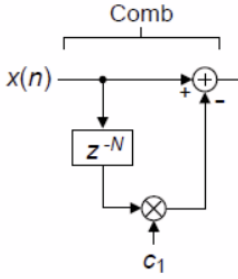

La primera etapa define la función:

$$v(n) = x(n) - c_1 \cdot x(n-N)$$

$$V(z) = X(z) - c_1 \cdot z^{-N} \cdot X(z)$$

$$V(z) = X(z) \cdot (1 - c_1 \cdot z^{-N})$$

$$H_1(z) = \frac{V(z)}{X(z)} = (1 - c_1 \cdot z^{-N})$$

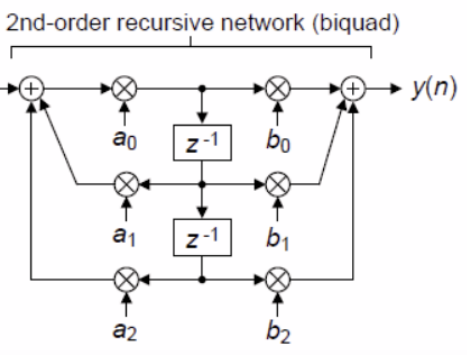

Segunda etapa:

$$\frac{w(n)}{a_0} = v(n) + a_1 \cdot w(n-1) + a_2 \cdot w(n-2)$$

$$v(n) = \frac{w(n)}{a_0} - a_1 \cdot w(n-1) - a_2 \cdot w(n-2)$$

$$V(z) = W(z) \cdot \left(\frac{1}{a_0} - a_1 \cdot z^{-1} - a_2 \cdot z^{-2}\right)$$

$$y(n) = b_0 \cdot w(n) + b_1 \cdot w(n-1) + b_2 \cdot w(n-2)$$

$$Y(z) = W(z) \cdot (b_0 + b_1 \cdot z^{-1} + b_2 \cdot z^{-2})$$

$$H_2(z) = \frac{Y(z)}{V(z)} = \frac{b_0 + b_1 \cdot z^{-1} + b_2 \cdot z^{-2}}{\frac{1}{a_0} - a_1 \cdot z^{-1} - a_2 \cdot z^{-2}}$$

$$\mathbf{H(z) = H_1(z) \cdot H_2(z) = (1 - c_1 \cdot z^{-N}) \cdot \frac{b_0 + b_1 \cdot z^{-1} + b_2 \cdot z^{-2}}{\frac{1}{a_0} - a_1 \cdot z^{-1} - a_2 \cdot z^{-2}}}$$

##**Filtro de media móvil**

###**Verificación**

$a_0=1$, $a_1=1$, $b_0=1/N$, y $c_1=1$. Considerar los demás coeficientes como nulos.

$$H(z) = (1 - 1 \cdot z^{-N}) \cdot \frac{1/N + 0 \cdot z^{-1} + 0 \cdot z^{-2}}{\frac{1}{1} - 1 \cdot z^{-1} - 0 \cdot z^{-2}}$$

$$H(z) = (1 - z^{-N}) \cdot \frac{1/N}{1 - z^{-1}}$$

$$H(z) = \frac{1}{N} \frac{1 - z^{-N}}{1 - z^{-1}}$$


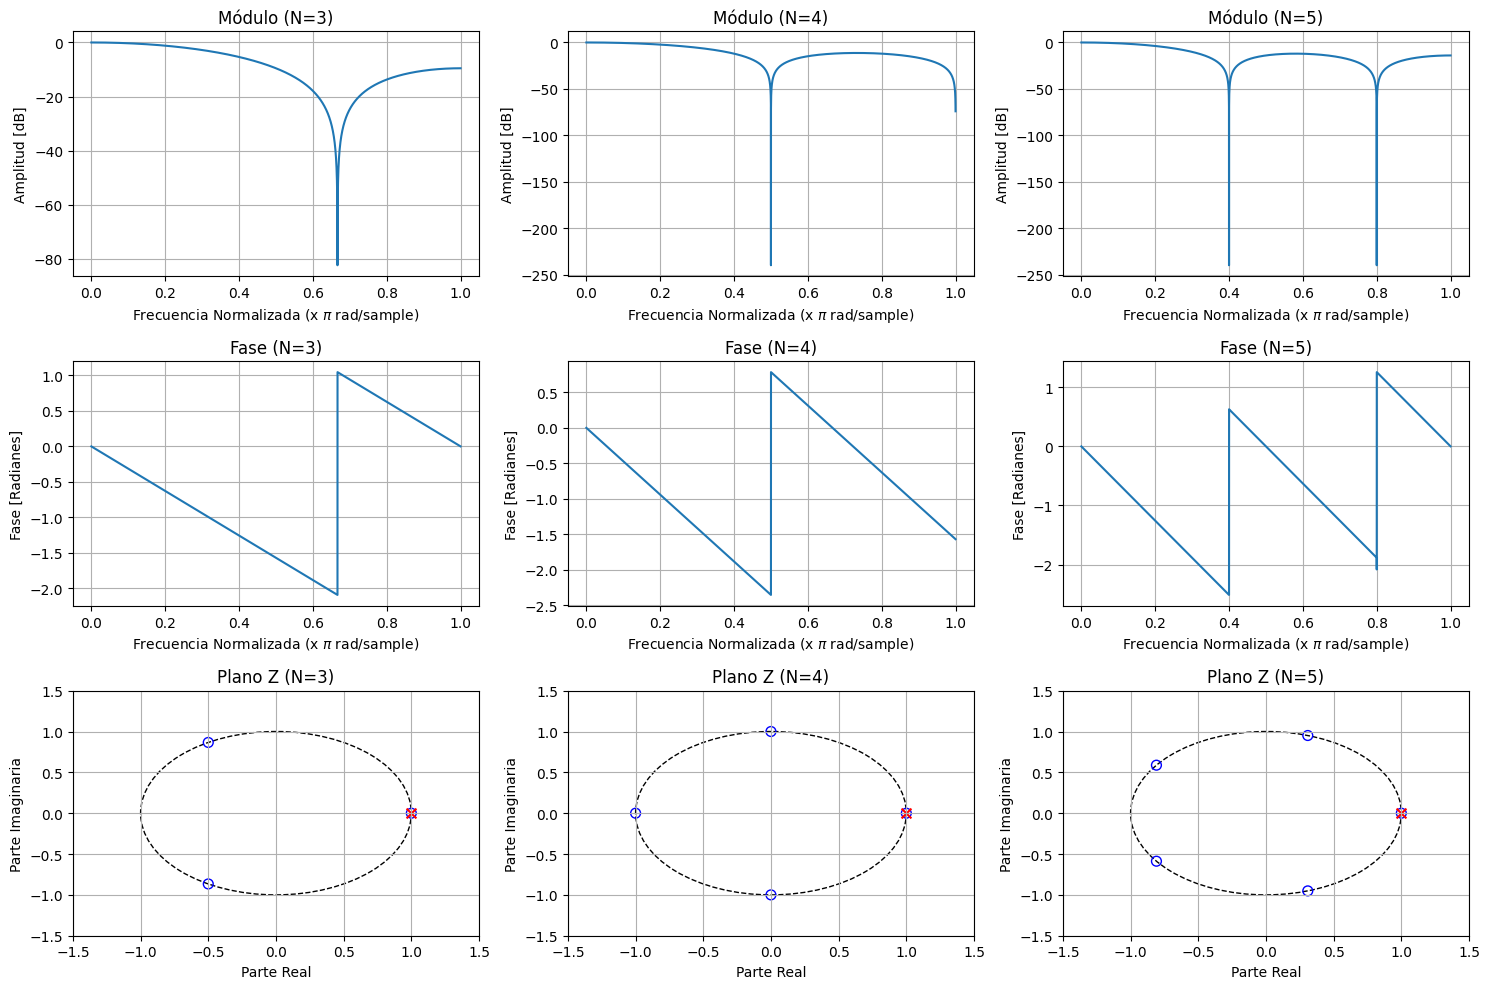

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

N_values = [3, 4, 5]

plt.figure(figsize=(15, 10))

for i, N in enumerate(N_values):
    b = np.zeros(N + 1)
    b[0] = 1/N
    b[N] = -1/N

    a = [1, -1]

    with np.errstate(invalid='ignore'):
        w, h = signal.freqz(b, a, worN=8000)

    plt.subplot(3, 3, i + 1)
    plt.plot(w / np.pi, 20 * np.log10(np.abs(h) + 1e-12))
    plt.title(f'Módulo (N={N})')
    plt.ylabel('Amplitud [dB]')
    plt.xlabel(r'Frecuencia Normalizada (x $\pi$ rad/sample)')
    plt.grid(True)

    plt.subplot(3, 3, i + 4)
    plt.plot(w / np.pi, np.angle(h))
    plt.title(f'Fase (N={N})')
    plt.ylabel('Fase [Radianes]')
    plt.xlabel(r'Frecuencia Normalizada (x $\pi$ rad/sample)')
    plt.grid(True)

    zeros, poles, _ = signal.tf2zpk(b, a)

    plt.subplot(3, 3, i + 7)
    unit_circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
    plt.gca().add_patch(unit_circle)

    plt.scatter(np.real(zeros), np.imag(zeros), s=50, edgecolors='b', facecolors='none', marker='o', label='Ceros')
    plt.scatter(np.real(poles), np.imag(poles), s=50, color='r', marker='x', label='Polos')
    plt.title(f'Plano Z (N={N})')
    plt.xlabel('Parte Real')
    plt.ylabel('Parte Imaginaria')
    plt.xlim([-1.5, 1.5])
    plt.ylim([-1.5, 1.5])
    plt.grid(True)

plt.tight_layout()
plt.show()

###**FIR o IIR**

Tiene un lazo de realimentación (el término $1 - z^{-1}$ en el denominador implica recursividad), lo que sugeriría que es IIR (Respuesta al Impulso Infinita). Sin embargo, el mapa de polos y ceros, el polo en $z=1$ se cancela con uno de los ceros del numerador en $z=1$. Al cancelarse matemáticamente el polo, la respuesta al impulso tiene una longitud finita. Por lo tanto, se comporta como un filtro FIR.

###**Ventajas frente a un FIR estándar**

En un FIR clásico de media móvil de longitud $N$, necesitas hacer $N$ sumas y $N$ multiplicaciones por cada muestra nueva. En cambio, la topología en cuestión requiere siempre solo 1 resta, 1 suma y 1 multiplicación por $1/N$, sin importar qué tan grande sea $N$. Es mucho más eficiente a nivel computacional.

###**Implementación de sistema**

Sí, se puede implementar con $N=7$ y todos sus coeficientes iguales a 1.

##**Filtro diferenciador**

###**Obtener** $\mathbf{y(n) = \frac{x(n) - x(n-2)}{2}}$

$$Y(z) = 0.5 \cdot X(z) - 0.5 \cdot z^{-2} \cdot X(z)$$

$$H_{diff}(z) = \frac{Y(z)}{X(z)} = 0.5 - 0.5 \cdot z^{-2}$$

Transferencia original:

$$H(z) = (1 - c_1 \cdot z^{-N}) \cdot \frac{b_0 + b_1 \cdot z^{-1} + b_2 \cdot z^{-2}}{\frac{1}{a_0} - a_1 \cdot z^{-1} - a_2 \cdot z^{-2}}$$

$c_1 = 0$

$b_0 = 0.5$

$b_1 = 0$

$b_2 = -0.5$

$a_0 = 1$

$a_1 = 0$

$a_2 = 0$

###**Evaluación de sistema**


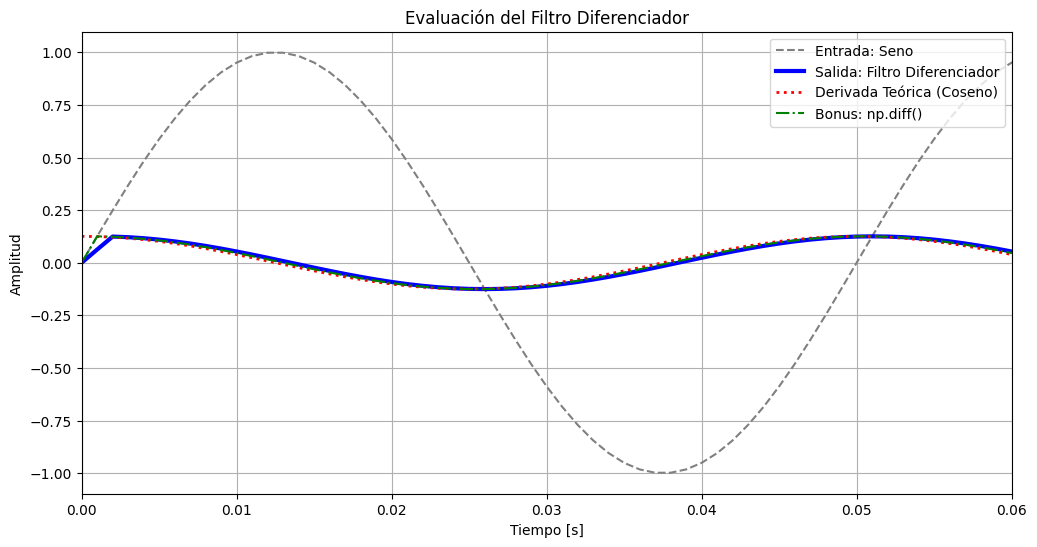

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

b = [0.5, 0.0, -0.5]
a = [1.0, 0.0, 0.0]

fs = 1000
t = np.arange(0, 0.1, 1/fs)
f_seno = 20
x = np.sin(2 * np.pi * f_seno * t)

y_filtrada = signal.lfilter(b, a, x)

y_teorica = np.cos(2 * np.pi * f_seno * t)
y_teorica = y_teorica * (np.max(y_filtrada) / np.max(y_teorica))

y_diff = np.diff(x)
y_diff = np.insert(y_diff, 0, 0)
y_diff = y_diff * (np.max(y_filtrada) / np.max(np.abs(y_diff))) # Escalar

plt.figure(figsize=(12, 6))
plt.plot(t, x, label='Entrada: Seno', linestyle='--', color='gray')
plt.plot(t, y_filtrada, label='Salida: Filtro Diferenciador', linewidth=3, color='blue')
plt.plot(t, y_teorica, label='Derivada Teórica (Coseno)', linestyle=':', color='red', linewidth=2)
plt.plot(t, y_diff, label='Bonus: np.diff()', linestyle='-.', color='green')

plt.title('Evaluación del Filtro Diferenciador')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.xlim(0, 0.06)
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

##**Filtro elimina continua**

###**Verificación**

$a_0=1$, $a_1=\beta$, $b_0=1$, $b_1=-1$; asumo los demás nulos.

$$H(z) = \frac{1 - z^{-1}}{1 - 0.9 \cdot z^{-1}}$$

Elimina la continua porque el numerador se hace cero cuando $z = 1$. En el círculo unitario, $z=1$ corresponde a la frecuencia $\Omega = 0$ (frecuencia continua o DC).

###**Determinar β**

Una caída de 3 dB equivale a que la potencia caiga a la mitad, es decir, que el módulo al cuadrado sea la mitad:

$$\vert{}H(e^{j 0.1\pi})\vert{}^2 = \frac{1}{2} \vert{}H(e^{j\pi})\vert{}^2$$

$$\vert{}H(e^{j\Omega})\vert{}^2 = H(e^{j\Omega}) \cdot H^*(e^{j\Omega}) = \frac{1 - e^{-j\Omega}}{1 - \beta e^{-j\Omega}} \cdot \frac{1 - e^{j\Omega}}{1 - \beta e^{j\Omega}}$$

$$\vert{}H(e^{j\Omega})\vert{}^2 = \frac{2 - 2\cos(\Omega)}{1 - 2\beta\cos(\Omega) + \beta^2}$$

Evalúo en $\Omega = \pi$

$$\vert{}H(e^{j\pi})\vert{}^2 = \frac{2 - 2(-1)}{1 - 2\beta(-1) + \beta^2} = \frac{4}{(1+\beta)^2}$$

Evalúo en $\Omega = 0.1\pi$:

$$\frac{2 - 2\cos(0.1\pi)}{1 - 2\beta\cos(0.1\pi) + \beta^2} = \frac{1}{2} \cdot \frac{4}{(1+\beta)^2}$$

$$\cos(0.1\pi) \cdot \beta^2 - 2\beta + \cos(0.1\pi) = 0$$

$$\beta = \frac{1 - \sqrt{1 - \cos^2(0.1\pi)}}{\cos(0.1\pi)} = \frac{1 - \sin(0.1\pi)}{\cos(0.1\pi)}$$

$$\beta \approx 0.7265$$

/tmp/ipykernel_1631/1696289807.py:17: RuntimeWarning: divide by zero encountered in log10
  mag_db = 20 * np.log10(np.abs(h))


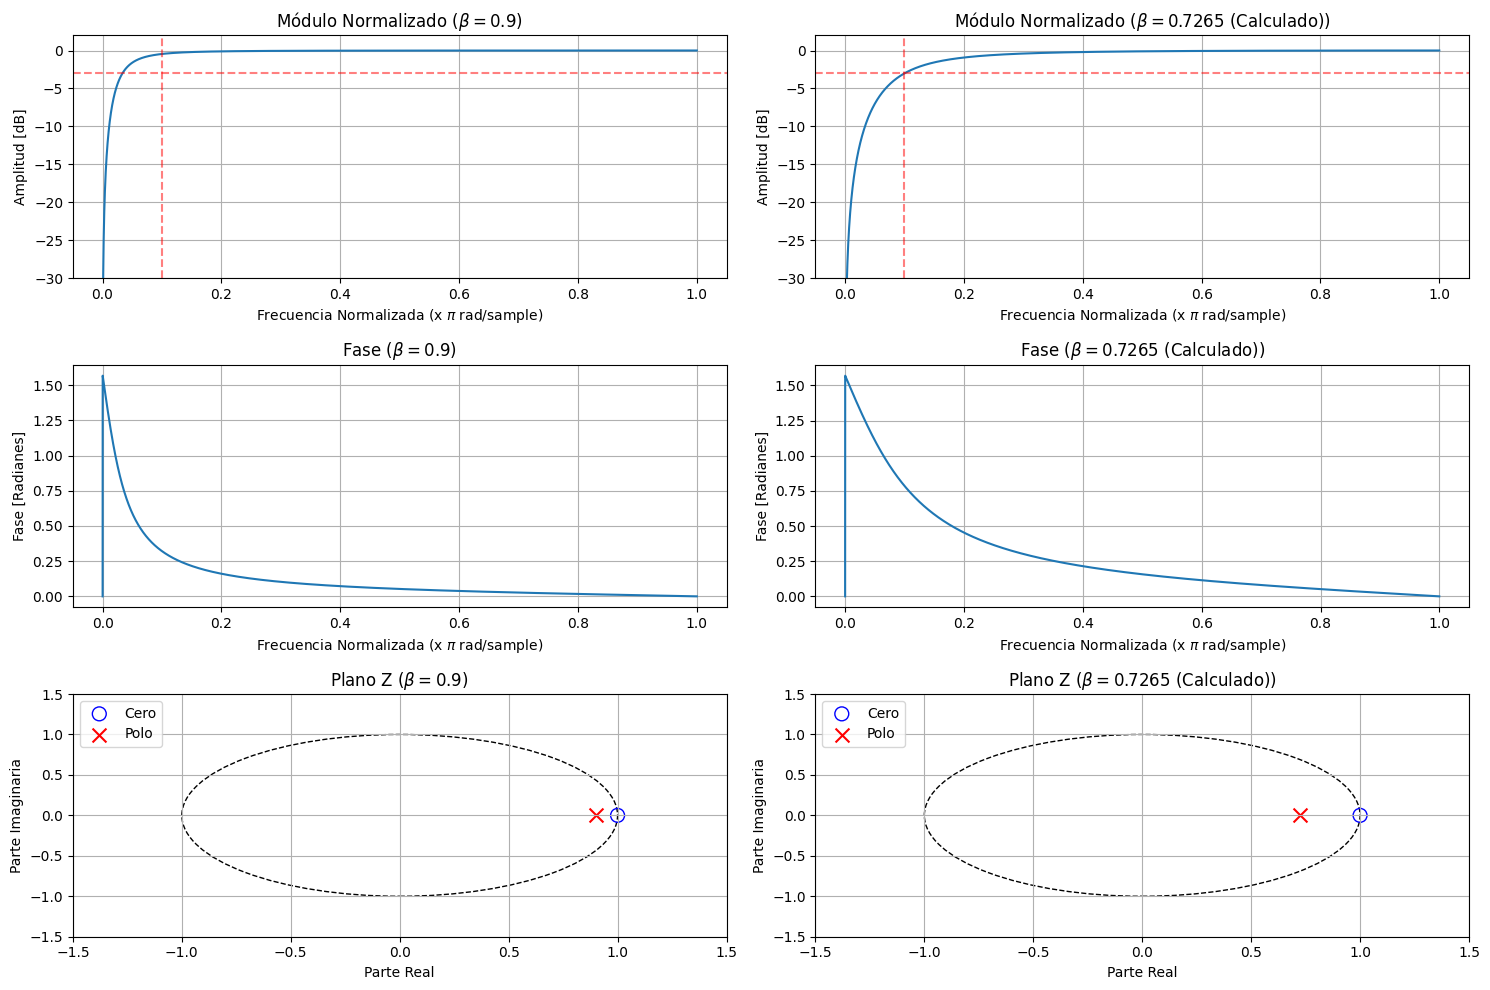

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

betas = [0.9, 0.72654]
labels = [r'$\beta = 0.9$', r'$\beta = 0.7265$ (Calculado)']

plt.figure(figsize=(15, 10))

for i, beta in enumerate(betas):
    b = [1, -1]
    a = [1, -beta]

    w, h = signal.freqz(b, a, worN=8000)

    plt.subplot(3, 2, i + 1)
    mag_db = 20 * np.log10(np.abs(h))
    mag_db -= mag_db[-1]

    plt.plot(w / np.pi, mag_db)
    plt.axvline(0.1, color='r', linestyle='--', alpha=0.5)
    plt.axhline(-3, color='r', linestyle='--', alpha=0.5)

    plt.title(f'Módulo Normalizado ({labels[i]})')
    plt.ylabel('Amplitud [dB]')
    plt.xlabel(r'Frecuencia Normalizada (x $\pi$ rad/sample)')
    plt.ylim([-30, 2])
    plt.grid(True)

    plt.subplot(3, 2, i + 3)
    plt.plot(w / np.pi, np.angle(h))
    plt.title(f'Fase ({labels[i]})')
    plt.ylabel('Fase [Radianes]')
    plt.xlabel(r'Frecuencia Normalizada (x $\pi$ rad/sample)')
    plt.grid(True)

    zeros, poles, _ = signal.tf2zpk(b, a)

    plt.subplot(3, 2, i + 5)
    unit_circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
    plt.gca().add_patch(unit_circle)

    plt.scatter(np.real(zeros), np.imag(zeros), s=100, edgecolors='b', facecolors='none', marker='o', label='Cero')
    plt.scatter(np.real(poles), np.imag(poles), s=100, color='r', marker='x', label='Polo')
    plt.title(f'Plano Z ({labels[i]})')
    plt.xlabel('Parte Real')
    plt.ylabel('Parte Imaginaria')
    plt.xlim([-1.5, 1.5])
    plt.ylim([-1.5, 1.5])
    plt.legend(loc='upper left')
    plt.grid(True)

plt.tight_layout()
plt.show()

##**Filtro peine**

###**Verificación**

Con $c_1 = -1$ y $N = 8$, asumiendo $a_0=1$, $b_0=1$, y el resto cero.

$$H(z) = 1 + z^{-8}$$

###**Propuesta**

$f_s = 8000$ Hz

###Nulls:

$1 + z^{-8} = 0 \implies z^8 = -1$

$\Omega = \frac{\pi}{8}, \frac{3\pi}{8}, \frac{5\pi}{8}, \frac{7\pi}{8}, -\frac{\pi}{8}, -\frac{3\pi}{8}, -\frac{5\pi}{8}, -\frac{7\pi}{8}$

$f = \frac{\Omega}{2\pi} f_s$:

$f_{null} = 500$ Hz, $1500$ Hz, $2500$ Hz, $3500$ Hz

###Peaks:

$z^{-8} = 1 \implies z^8 = 1$

$\Omega = 0, \frac{\pi}{4}, \frac{\pi}{2}, \frac{3\pi}{4}, \pi$

$f_{peak} = 0$ Hz, $1000$ Hz, $2000$ Hz, $3000$ Hz, $4000$ Hz




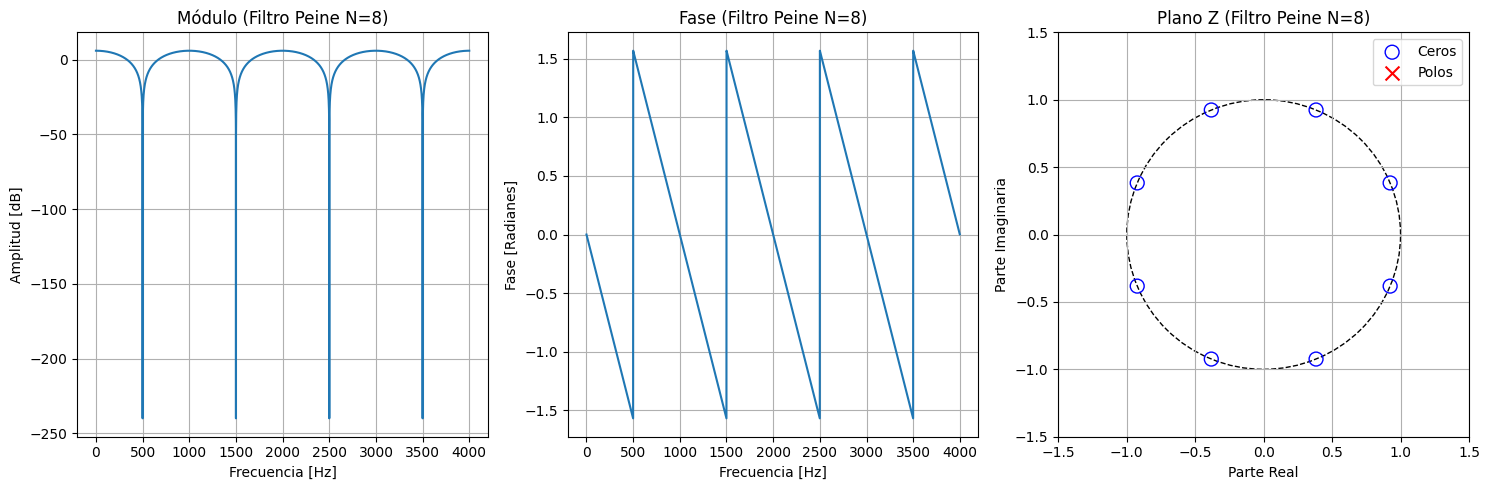

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

N = 8
fs = 8000

b = np.zeros(N + 1)
b[0] = 1
b[N] = 1
a = [1]

plt.figure(figsize=(15, 5))

w, h = signal.freqz(b, a, worN=8000)
f = (w / (2 * np.pi)) * fs

plt.subplot(1, 3, 1)
with np.errstate(divide='ignore'):
    plt.plot(f, 20 * np.log10(np.abs(h) + 1e-12))
plt.title('Módulo (Filtro Peine N=8)')
plt.ylabel('Amplitud [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.xticks([0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000])
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(f, np.angle(h))
plt.title('Fase (Filtro Peine N=8)')
plt.ylabel('Fase [Radianes]')
plt.xlabel('Frecuencia [Hz]')
plt.grid(True)

zeros, poles, _ = signal.tf2zpk(b, a)

plt.subplot(1, 3, 3)
unit_circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
plt.gca().add_patch(unit_circle)

plt.scatter(np.real(zeros), np.imag(zeros), s=100, edgecolors='b', facecolors='none', marker='o', label='Ceros')
plt.scatter(np.real(poles), np.imag(poles), s=100, color='r', marker='x', label='Polos')

plt.title('Plano Z (Filtro Peine N=8)')
plt.xlabel('Parte Real')
plt.ylabel('Parte Imaginaria')
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

##**Filtro pasatodo**

$$H(s) = \frac{s - \omega_0}{s + \omega_0}$$

$$s = \frac{2}{T_s} \frac{1 - z^{-1}}{1 + z^{-1}}$$

Para simplificar la expresión: $K = \frac{2}{T_s}$

$$H(z) = \frac{K \frac{1 - z^{-1}}{1 + z^{-1}} - \omega_0}{K \frac{1 - z^{-1}}{1 + z^{-1}} + \omega_0}$$

$$H(z) = \frac{K(1 - z^{-1}) - \omega_0(1 + z^{-1})}{K(1 - z^{-1}) + \omega_0(1 + z^{-1})}$$

$$H(z) = \frac{(K - \omega_0) - (K + \omega_0)z^{-1}}{(K + \omega_0) + (K - \omega_0)z^{-1}}$$

$$H(z) = \frac{\frac{K - \omega_0}{K + \omega_0} - z^{-1}}{1 + \frac{K - \omega_0}{K + \omega_0}z^{-1}}$$

Para simplificar: $\alpha = \frac{K - \omega_0}{K + \omega_0}$

$$H(z) = \frac{\alpha - z^{-1}}{1 + \alpha z^{-1}}$$

Par implementar:

$$H_{biquad}(z) = (1 - c_1 \cdot z^{-N}) \cdot \frac{b_0 + b_1 \cdot z^{-1} + b_2 \cdot z^{-2}}{\frac{1}{a_0} - a_1 \cdot z^{-1} - a_2 \cdot z^{-2}}$$

$c_1 = 0, a_0 = 1, a_1 = -\alpha, a_2 = 0, b_0 = \alpha, b_1 = -1, b_2 = 0$